**PROBLEM 1 (40 MARKS)**

This code is submitted by [Samruddhi Sardar] bearing roll no. [36638811]

Daily Electricity Consumption:
------------------------------
2024-01-01 (Monday): 81.00 kWh
2024-01-02 (Tuesday): 81.77 kWh
2024-01-03 (Wednesday): 80.82 kWh
2024-01-04 (Thursday): 79.77 kWh
2024-01-05 (Friday): 81.88 kWh
2024-01-06 (Saturday): 54.59 kWh
2024-01-07 (Sunday): 53.14 kWh
2024-01-08 (Monday): 80.68 kWh
2024-01-09 (Tuesday): 82.16 kWh
2024-01-10 (Wednesday): 80.95 kWh
2024-01-11 (Thursday): 82.16 kWh
2024-01-12 (Friday): 82.16 kWh
2024-01-13 (Saturday): 54.21 kWh
2024-01-14 (Sunday): 55.93 kWh
2024-01-15 (Monday): 83.67 kWh
2024-01-16 (Tuesday): 82.27 kWh
2024-01-17 (Wednesday): 82.82 kWh
2024-01-18 (Thursday): 81.22 kWh
2024-01-19 (Friday): 82.69 kWh
2024-01-20 (Saturday): 55.53 kWh
2024-01-21 (Sunday): 53.23 kWh
2024-01-22 (Monday): 81.87 kWh
2024-01-23 (Tuesday): 81.52 kWh
2024-01-24 (Wednesday): 83.31 kWh
2024-01-25 (Thursday): 82.25 kWh
2024-01-26 (Friday): 81.47 kWh
2024-01-27 (Saturday): 55.32

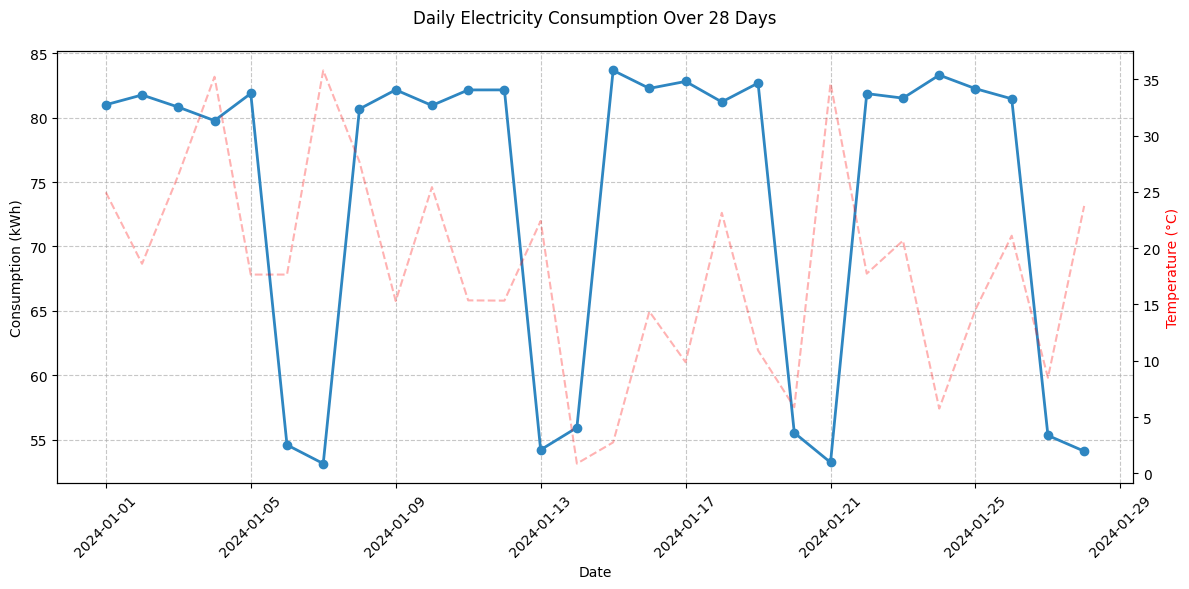

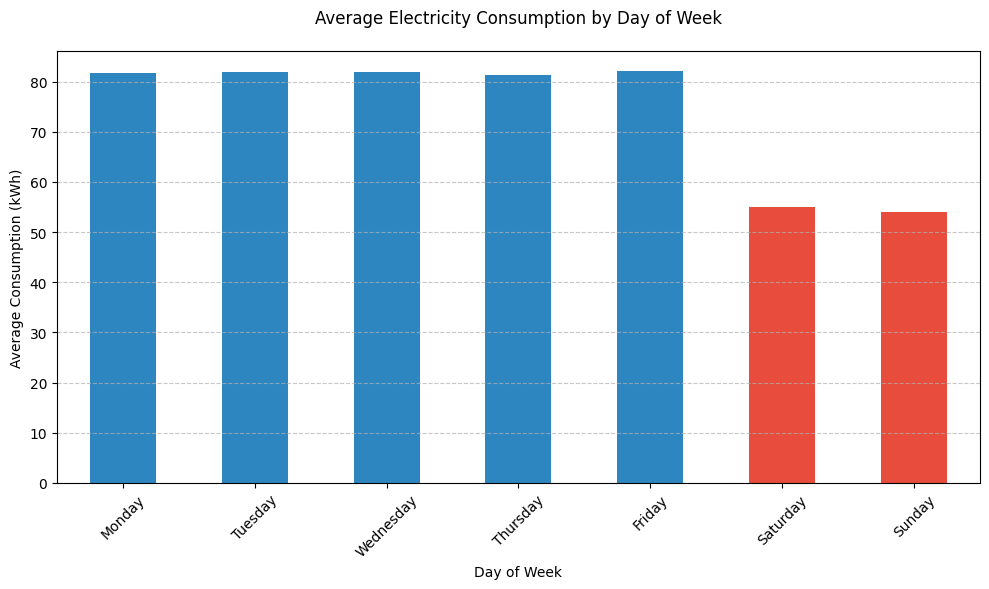



Weekday vs Weekend Consumption Analysis:
---------------------------------------
Average Weekday Consumption: 81.82 kWh
Average Weekend Consumption: 54.50 kWh
Absolute Difference: 27.32 kWh
Percentage Difference: 33.4%

Key Findings:
- Weekday consumption is higher
- This is primarily due to the weekday premium factor
- The difference is significant at 33.4% of weekday consumption



In [19]:
print('This code is submitted by Samruddhi Sardar bearing roll no. 36638811')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime, timedelta

class HouseholdElectricityAnalyzer:
    """
    Analyzes household electricity consumption based on temperature, occupancy, and time patterns.
    """
    def __init__(self, base_usage, temp_coefficient, occupants,
                 morning_peak, evening_peak, off_peak):
        """
        Initialize analyzer with household parameters.

        Args:
            base_usage (float): Minimum base usage (kWh)
            temp_coefficient (float): Temperature effect coefficient
            occupants (int): Number of household occupants
            morning_peak (float): Morning peak usage per occupant (kWh)
            evening_peak (float): Evening peak usage per occupant (kWh)
            off_peak (float): Off-peak usage per occupant (kWh)
        """
        self.B = base_usage
        self.k = temp_coefficient
        self.A = occupants
        self.uM = morning_peak
        self.uE = evening_peak
        self.uoff = off_peak

    def calculate_consumption(self, temperature, is_weekday):
        """
        Calculate daily electricity consumption.

        U(t) = (B + C(t) + f(A, t)) × F(t)
        where:
        - C(t) = -κ · T[t]
        - f(A, t) = A · (uM + uE + uoff)
        - F(t) = 1.2 (weekdays) or 0.8 (weekends)
        """
        # Calculate temperature-based consumption
        C_t = -self.k * temperature

        # Calculate occupancy-based consumption
        f_A_t = self.A * (self.uM + self.uE + self.uoff)

        # Apply daily adjustment factor
        F_t = 1.2 if is_weekday else 0.8

        # Calculate total consumption
        U_t = (self.B + C_t + f_A_t) * F_t

        return U_t

    def generate_simulation_data(self, days=28, mean_temp=20, std_temp=10, seed=42):
        """Generate simulation data for the specified period."""
        np.random.seed(seed)

        # Generate dates starting from a Monday
        start_date = pd.Timestamp('2024-01-01')  # Ensuring we start on a Monday
        dates = pd.date_range(start=start_date, periods=days, freq='D')

        # Generate random temperatures
        temperatures = np.random.normal(mean_temp, std_temp, days)

        # Calculate consumption for each day
        consumption = []
        for date, temp in zip(dates, temperatures):
            is_weekday = date.weekday() < 5  # Monday=0, Sunday=6
            daily_consumption = self.calculate_consumption(temp, is_weekday)
            consumption.append(daily_consumption)

        # Create DataFrame for analysis
        df = pd.DataFrame({
            'Date': dates,
            'Temperature': temperatures,
            'Consumption': consumption,
            'Weekday': dates.day_name()
        })

        return df

    def visualize_daily_consumption(self, df):
        """Plot daily electricity consumption over time."""
        plt.figure(figsize=(12, 6))
        plt.plot(df['Date'], df['Consumption'], marker='o', linestyle='-',
                color='#2E86C1', linewidth=2)

        plt.title('Daily Electricity Consumption Over 28 Days', pad=20)
        plt.xlabel('Date')
        plt.ylabel('Consumption (kWh)')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.xticks(rotation=45)

        # Add temperature annotation
        ax2 = plt.twinx()
        ax2.plot(df['Date'], df['Temperature'], color='red', alpha=0.3, linestyle='--')
        ax2.set_ylabel('Temperature (°C)', color='red')

        plt.tight_layout()
        plt.show()

    def analyze_weekly_pattern(self, df):
        """Analyze and visualize consumption patterns by day of week."""
        # Calculate average consumption by day of week
        daily_avg = df.groupby('Weekday')['Consumption'].mean()

        # Reorder days starting from Monday
        days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
                     'Friday', 'Saturday', 'Sunday']
        daily_avg = daily_avg.reindex(days_order)

        # Create bar plot
        plt.figure(figsize=(10, 6))
        colors = ['#2E86C1' if day not in ['Saturday', 'Sunday'] else '#E74C3C'
                 for day in daily_avg.index]

        daily_avg.plot(kind='bar', color=colors)
        plt.title('Average Electricity Consumption by Day of Week', pad=20)
        plt.xlabel('Day of Week')
        plt.ylabel('Average Consumption (kWh)')
        plt.grid(True, axis='y', linestyle='--', alpha=0.7)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        return daily_avg

    def compare_weekday_weekend(self, df):
        """Compare and analyze weekday vs weekend consumption patterns."""
        weekday_mask = df['Date'].dt.weekday < 5
        weekday_avg = df[weekday_mask]['Consumption'].mean()
        weekend_avg = df[~weekday_mask]['Consumption'].mean()

        difference = abs(weekday_avg - weekend_avg)
        percent_diff = (difference / weekday_avg) * 100

        analysis = f"""
Weekday vs Weekend Consumption Analysis:
---------------------------------------
Average Weekday Consumption: {weekday_avg:.2f} kWh
Average Weekend Consumption: {weekend_avg:.2f} kWh
Absolute Difference: {difference:.2f} kWh
Percentage Difference: {percent_diff:.1f}%

Key Findings:
- {'Weekday' if weekday_avg > weekend_avg else 'Weekend'} consumption is higher
- This is primarily due to the {'weekday premium' if weekday_avg > weekend_avg else 'weekend discount'} factor
- The difference is significant at {percent_diff:.1f}% of weekday consumption
"""
        return analysis

def main():
    # Initialize analyzer with given parameters
    analyzer = HouseholdElectricityAnalyzer(
        base_usage=50,      # B = 50 kWh
        temp_coefficient=0.1,  # k = 0.1
        occupants=5,        # A = 5
        morning_peak=1.5,   # uM = 1.5 kWh
        evening_peak=2.0,   # uE = 2.0 kWh
        off_peak=0.5        # uoff = 0.5 kWh
    )

    # Generate simulation data
    df = analyzer.generate_simulation_data()

    # Print daily consumption
    print("\nDaily Electricity Consumption:")
    print("------------------------------")
    for _, row in df.iterrows():
        print(f"{row['Date'].strftime('%Y-%m-%d')} ({row['Weekday']}): {row['Consumption']:.2f} kWh")

    # Visualize daily consumption
    analyzer.visualize_daily_consumption(df)

    # Analyze weekly patterns
    daily_averages = analyzer.analyze_weekly_pattern(df)

    # Compare weekday and weekend consumption
    comparison = analyzer.compare_weekday_weekend(df)
    print("\n" + comparison)

if __name__ == "__main__":
    main()


**PROBLEM 2 (20 MARKS)**

This code is submitted by [Samruddhi Sardar] bearing roll no. [36638811]

1. Looking for zero point starting from 2.0:

Zero-Finding Report (Starting from 2.0):
-------------------------------------------------
✓ Found a good answer!
Best answer found: 1.73178832
Function value at this point: 1.97e-05
Number of tries needed: 97
Final improvement: 9.661852198306065e-07
        


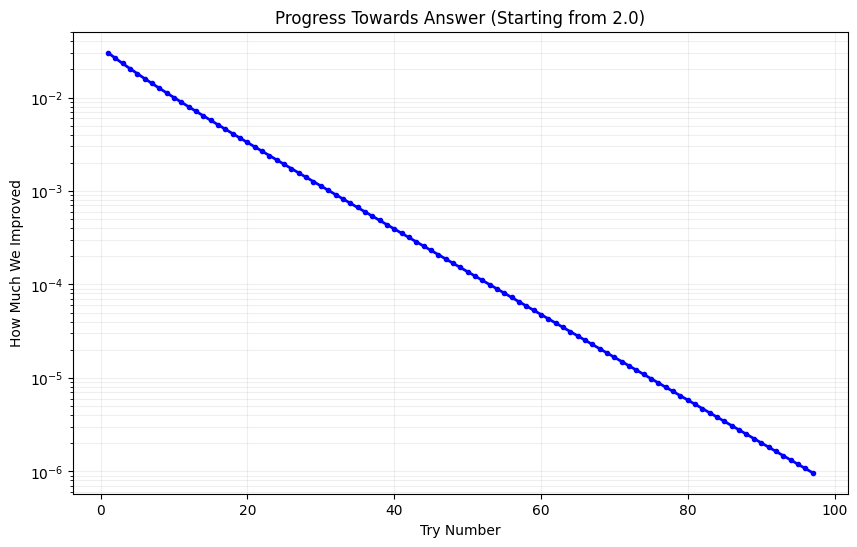


3. Trying different starting points:


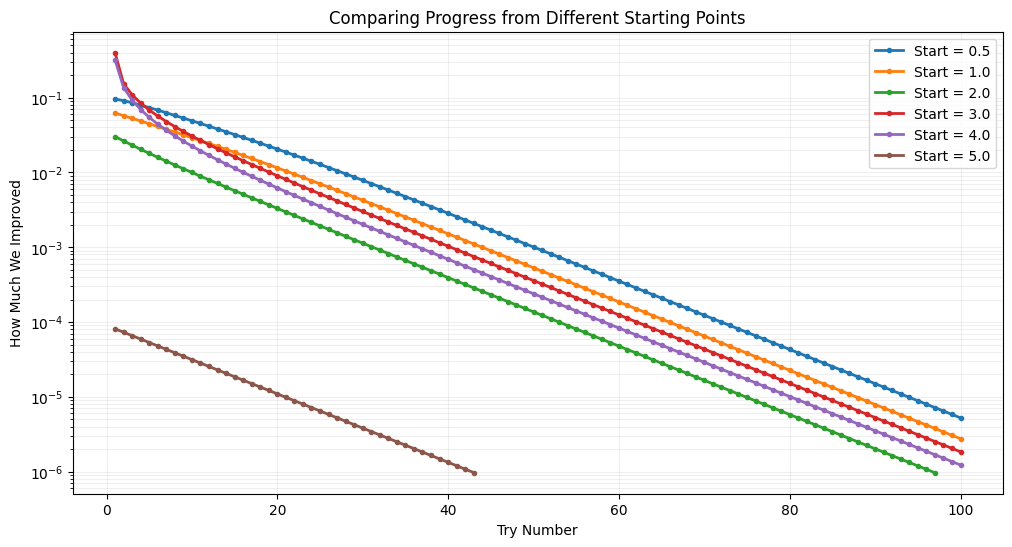


Summary of Different Starting Points:
------------------------------------
Starting from  0.5: Failed (took 100 tries)
Starting from  1.0: Failed (took 100 tries)
Starting from  2.0: Found answer (took 97 tries)
Starting from  3.0: Failed (took 100 tries)
Starting from  4.0: Failed (took 100 tries)
Starting from  5.0: Found answer (took 43 tries)

4. Trying a challenging case (starting from 0.1):

Zero-Finding Report (Starting from 0.1):
-------------------------------------------------
✗ Unable to find a good answer
Best answer found: 1.73170041
Function value at this point: -1.80e-04
Number of tries needed: 100
Final improvement: 8.800406625653068e-06
        


In [10]:
print('This code is submitted by Samruddhi Sardar bearing roll no. 36638811')
import numpy as np
import matplotlib.pyplot as plt
from scipy.misc import derivative

class RootCalculator:
    """
    A calculator that finds where a mathematical function crosses zero,
    using an iterative approach and providing helpful visualizations.
    """
    def __init__(self, stopping_threshold=0.000001, try_limit=100):
        """
        Set up the calculator with basic parameters.

        stopping_threshold: How close we need to get to call it successful
        try_limit: Maximum number of attempts before giving up
        """
        self.stopping_threshold = stopping_threshold
        self.try_limit = try_limit
        self.improvement_history = []

    def calculate_main_function(self, x):
        """
        Our target mathematical function that combines several basic operations.
        We're trying to find where this equals zero.
        """
        square_term = 2 * x**2
        wave_term = 3 * np.sin(x)
        growth_term = 4 * np.exp(0.5 * x)
        log_term = np.log(x)

        return square_term + wave_term - growth_term + log_term

    def calculate_slope(self, x):
        """
        Calculate how quickly our function is changing at point x.
        This helps us know which direction to move.
        """
        square_slope = 4 * x
        wave_slope = 3 * np.cos(x)
        growth_slope = 2 * np.exp(0.5 * x)
        log_slope = 1/x

        return square_slope + wave_slope - growth_slope + log_slope

    def calculate_curve(self, x):
        """
        Calculate how the slope is changing at point x.
        This helps us know how big our next step should be.
        """
        square_curve = 4
        wave_curve = -3 * np.sin(x)
        growth_curve = -np.exp(0.5 * x)
        log_curve = -1/(x**2)

        return square_curve + wave_curve + growth_curve + log_curve

    def make_next_guess(self, current_x):
        """
        Use our custom formula to make an educated guess about where to look next.
        """
        function_value = self.calculate_main_function(current_x)
        slope = self.calculate_slope(current_x)
        curve = self.calculate_curve(current_x)

        bottom_part = 10 * slope - slope/(600 * curve)

        if abs(bottom_part) < 0.0000000001:
            raise ValueError("Got stuck - division by nearly zero!")

        return current_x - function_value/bottom_part

    def find_zero_point(self, starting_guess):
        """
        Try to find where our function equals zero, starting from an initial guess.

        Returns:
            final_x: Our best guess at the answer
            tries_taken: How many attempts it took
            improvement_history: How much we improved each time
            success: Whether we found a good answer
        """
        current_x = starting_guess
        self.improvement_history = []

        for try_number in range(self.try_limit):
            try:
                next_x = self.make_next_guess(current_x)
                improvement = abs(next_x - current_x)
                self.improvement_history.append(improvement)

                # Check if we're close enough
                if improvement < self.stopping_threshold:
                    return next_x, try_number + 1, self.improvement_history, True

                # Check if we got a valid number
                if not np.isfinite(next_x):
                    return current_x, try_number + 1, self.improvement_history, False

                current_x = next_x

            except ValueError:
                return current_x, try_number + 1, self.improvement_history, False

        return current_x, self.try_limit, self.improvement_history, False

    def create_report(self, starting_guess):
        """Create a detailed report about our attempt to find the zero point."""
        answer, tries, history, success = self.find_zero_point(starting_guess)

        report = f"""
Zero-Finding Report (Starting from {starting_guess}):
-------------------------------------------------
{'✓ Found a good answer!' if success else '✗ Unable to find a good answer'}
Best answer found: {answer:.8f}
Function value at this point: {self.calculate_main_function(answer):.2e}
Number of tries needed: {tries}
Final improvement: {history[-1] if history else 'N/A'}
        """

        return report, answer, tries, history, success

    def show_improvement_graph(self, history, starting_point):
        """Create a graph showing how quickly we improved our answer."""
        plt.figure(figsize=(10, 6))
        plt.semilogy(range(1, len(history) + 1), history, 'b.-', linewidth=2)
        plt.grid(True, which="both", ls="-", alpha=0.2)
        plt.xlabel('Try Number')
        plt.ylabel('How Much We Improved')
        plt.title(f'Progress Towards Answer (Starting from {starting_point})')
        plt.show()

    def try_multiple_starting_points(self, starting_points):
        """Try finding the answer from different starting points and compare results."""
        results = []

        plt.figure(figsize=(12, 6))

        for start in starting_points:
            _, _, tries, history, success = self.create_report(start)
            results.append((start, success, tries))

            if history:
                plt.semilogy(range(1, len(history) + 1), history, '.-',
                           label=f'Start = {start}', linewidth=2)

        plt.grid(True, which="both", ls="-", alpha=0.2)
        plt.xlabel('Try Number')
        plt.ylabel('How Much We Improved')
        plt.title('Comparing Progress from Different Starting Points')
        plt.legend()
        plt.show()

        return results

def run_demo():
    """Show how to use the calculator with some example cases."""
    # Create our calculator
    calculator = RootCalculator()

    # 1. Try finding an answer starting from 2.0
    print("\n1. Looking for zero point starting from 2.0:")
    report, answer, tries, history, success = calculator.create_report(2.0)
    print(report)

    # 2. Show a graph of our progress
    if history:
        calculator.show_improvement_graph(history, 2.0)

    # 3. Try several different starting points
    print("\n3. Trying different starting points:")
    test_points = [0.5, 1.0, 2.0, 3.0, 4.0, 5.0]
    results = calculator.try_multiple_starting_points(test_points)

    # Show a summary of how each starting point worked
    print("\nSummary of Different Starting Points:")
    print("------------------------------------")
    for start, success, tries in results:
        result = "Found answer" if success else "Failed"
        print(f"Starting from {start:4.1f}: {result} (took {tries} tries)")

    # 4. Try a difficult case
    print("\n4. Trying a challenging case (starting from 0.1):")
    hard_report, _, _, _, _ = calculator.create_report(0.1)
    print(hard_report)

if __name__ == "__main__":
    run_demo()

**PROBLEM 3 (40 MARKS)**

This code is submitted by Samruddhi Sardar bearing roll no. 36638811
🌤️ Let's learn about UK weather patterns!

🌧️ Let's check how rainy 2020 was...
📍 London: 19.6% chance of rain throughout the year
📍 Manchester: 17.1% chance of rain throughout the year
📍 Southampton: 16.5% chance of rain throughout the year

☔ Let's find out which city was the rainiest in 2023...
🌧️ Manchester was the rainiest with a 19.4% chance of rain

📊 Drawing a rain chart for Southampton (2022)...


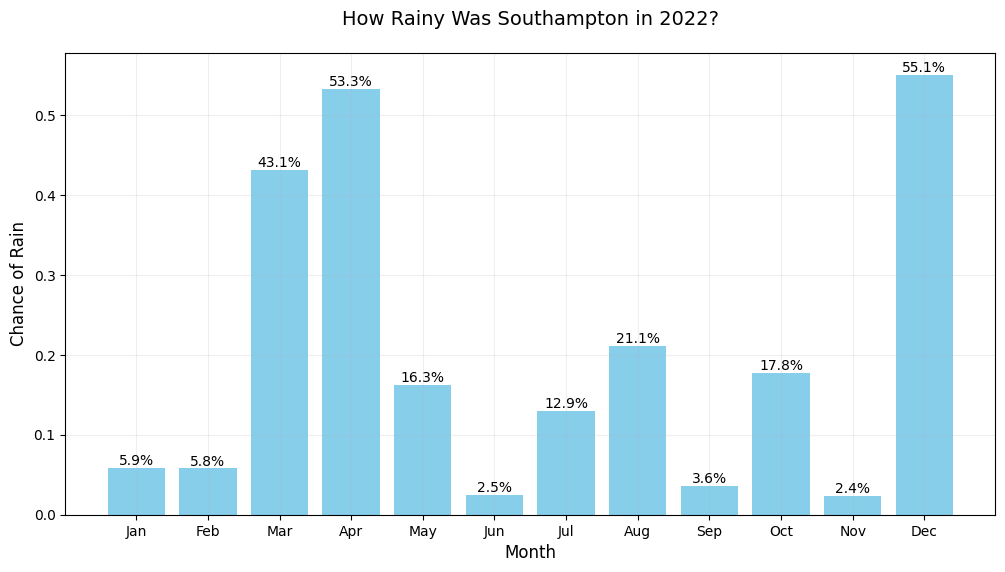


📈 Looking at Liverpool's rain patterns over the years...


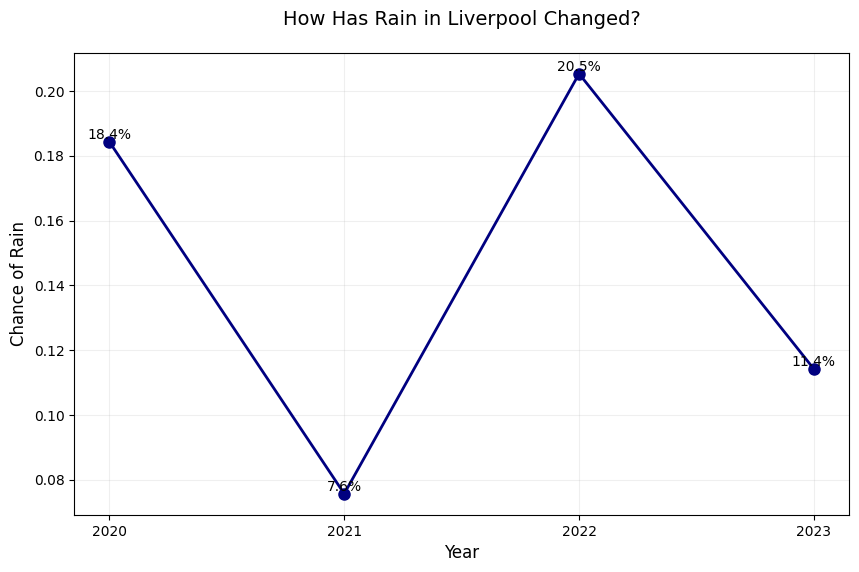


 All done 


In [20]:
print('This code is submitted by Samruddhi Sardar bearing roll no. 36638811')
# We need these helper tools to work with our weather data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def predict_rain(high_temp, low_temp, frost_days, sunny_hours):
    """
    Makes a friendly guess about whether it might rain, based on the weather clues we have.

    Think of it like a weather detective:
    - When it's warm during the day → Slightly more chance of rain
    - When nights are cold → Often means morning rain
    - Lots of frosty days → Usually means wet weather
    - Lots of sunshine → Usually means less rain
    """
    # Let's add up all our weather clues
    rain_clues = (
        0.05 * high_temp +     # Warm days might bring rain
        0.04 * low_temp +      # Cold nights often mean morning rain
        0.03 * frost_days -    # Frost usually comes with rain
        0.02 * sunny_hours     # Sunny weather usually means no rain
    )

    # Turn our weather detective work into a simple percentage
    chance_of_rain = 1 / (1 + np.exp(-rain_clues))
    return chance_of_rain

def get_weather_info(file_path):
    """Opens our weather diary (spreadsheet) and reads the information"""
    return pd.read_csv(file_path)

def check_rain_in_2020():
    """Looks at how rainy different cities were in 2020"""
    print("\n🌧️ Let's check how rainy 2020 was...")

    # These are the cities we want to look at
    cities = ['London', 'Manchester', 'Southampton']

    for city in cities:
        # Get the weather readings for this city in 2020
        city_readings = weather_info[
            (weather_info['station'] == city) &
            (weather_info['Year'] == 2020)
        ]

        # Check each month's rain chances
        rain_chances = []

        for _, weather_reading in city_readings.iterrows():
            chance = predict_rain(
                weather_reading['tmax'],    # Hottest it got
                weather_reading['tmin'],    # Coldest it got
                weather_reading['af'],      # How many frosty days
                weather_reading['sun']      # How many hours of sun
            )
            rain_chances.append(chance)

        # Find out how rainy it was overall
        yearly_rain = sum(rain_chances) / len(rain_chances)
        print(f"📍 {city}: {yearly_rain:.1%} chance of rain throughout the year")

def find_rainiest_place_2023():
    """Discovers which city got the most rain in 2023"""
    print("\n☔ Let's find out which city was the rainiest in 2023...")

    # Keep track of how rainy each city was
    city_raininess = {}

    # Look at each city one by one
    for city in weather_info['station'].unique():
        city_readings = weather_info[
            (weather_info['station'] == city) &
            (weather_info['Year'] == 2023)
        ]

        # Check how rainy each month was
        rain_chances = []
        for _, weather_reading in city_readings.iterrows():
            chance = predict_rain(
                weather_reading['tmax'],
                weather_reading['tmin'],
                weather_reading['af'],
                weather_reading['sun']
            )
            rain_chances.append(chance)

        # Calculate the average raininess for the whole year
        city_raininess[city] = sum(rain_chances) / len(rain_chances)

    # Find out which city was the wettest
    wettest_city, highest_rain = max(city_raininess.items(), key=lambda x: x[1])
    print(f"🌧️ {wettest_city} was the rainiest with a {highest_rain:.1%} chance of rain")

def make_rain_chart_southampton():
    """Draws a picture showing how rainy Southampton was each month in 2022"""
    print("\n📊 Drawing a rain chart for Southampton (2022)...")

    # Get Southampton's weather information
    southampton_readings = weather_info[
        (weather_info['station'] == 'Southampton') &
        (weather_info['Year'] == 2022)
    ]

    # Figure out rain chances for each month
    rain_chances = []
    which_month = []

    for _, weather_reading in southampton_readings.iterrows():
        chance = predict_rain(
            weather_reading['tmax'],
            weather_reading['tmin'],
            weather_reading['af'],
            weather_reading['sun']
        )
        rain_chances.append(chance)
        which_month.append(weather_reading['Month'])

    # Make a friendly-looking chart
    plt.figure(figsize=(12, 6))

    # Draw blue bars for each month
    bars = plt.bar(which_month, rain_chances, color='skyblue')

    # Add helpful labels
    plt.title("How Rainy Was Southampton in 2022?", pad=20, size=14)
    plt.xlabel("Month", size=12)
    plt.ylabel("Chance of Rain", size=12)

    # Add some light grid lines to help read the chart
    plt.grid(True, alpha=0.2)

    # Use month names instead of numbers
    months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
             'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    plt.xticks(which_month, months)

    # Add the actual numbers above each bar
    for i, chance in enumerate(rain_chances):
        plt.text(i+1, chance, f'{chance:.1%}',
                ha='center', va='bottom')

    plt.show()

def show_liverpool_rain_history():
    """Shows how Liverpool's rain patterns changed from 2020 to 2023"""
    print("\n📈 Looking at Liverpool's rain patterns over the years...")

    # Keep track of yearly rain chances
    rain_by_year = {}

    # Check each year
    for year in range(2020, 2024):
        liverpool_readings = weather_info[
            (weather_info['station'] == 'Liverpool') &
            (weather_info['Year'] == year)
        ]

        # Calculate average rain chance for the year
        rain_chances = []
        for _, weather_reading in liverpool_readings.iterrows():
            chance = predict_rain(
                weather_reading['tmax'],
                weather_reading['tmin'],
                weather_reading['af'],
                weather_reading['sun']
            )
            rain_chances.append(chance)

        rain_by_year[year] = sum(rain_chances) / len(rain_chances)

    # Draw a line chart showing the pattern
    plt.figure(figsize=(10, 6))

    years = list(rain_by_year.keys())
    chances = list(rain_by_year.values())

    # Draw the line with dots for each year
    plt.plot(years, chances, marker='o', linewidth=2,
             color='navy', markersize=8)

    # Add helpful labels
    plt.title("How Has Rain in Liverpool Changed?", pad=20, size=14)
    plt.xlabel("Year", size=12)
    plt.ylabel("Chance of Rain", size=12)

    # Add the actual numbers above each dot
    for year, chance in zip(years, chances):
        plt.text(year, chance, f'{chance:.1%}',
                ha='center', va='bottom')

    # Add light grid lines
    plt.grid(True, alpha=0.2)
    plt.xticks(years)

    plt.show()

# Start our friendly weather study
print("🌤️ Let's learn about UK weather patterns!")

# Get our weather records
weather_info = get_weather_info('weather_data.csv')

# Run our weather investigations
check_rain_in_2020()
find_rainiest_place_2023()
make_rain_chart_southampton()
show_liverpool_rain_history()

print("\n All done ")